**MNIST Handwritten Digit Clasification using Deep Learning (Neural Network)**

In [112]:
from typing_extensions import TypeForm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
import tensorflow as tf
tf.random.set_seed(3)
from tensorflow import keras
from keras.datasets import mnist
from tensorflow.math import confusion_matrix

Loading the MNIST data from keras.datasets

In [113]:
(X_train , Y_train) , (X_test , Y_test) = mnist.load_data()

(X_train , Y_train) , (X_test , Y_test) eikhane ei bracket gula must dawa lagbe na hole wrong dekhay

In [114]:
type(X_train)

numpy.ndarray

In [115]:
# shape of the numpy arrays
print(X_train.shape, Y_train.shape, X_test.shape, Y_test.shape)

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


Training data = 60,000 Images

Test data = 10,000 Images

Image dimension  --> 28 x 28

Grayscale Image  --> 1 channel

In [116]:
#printing the 1st Image

print(X_train[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 18

In [117]:
X_train[0].shape

(28, 28)

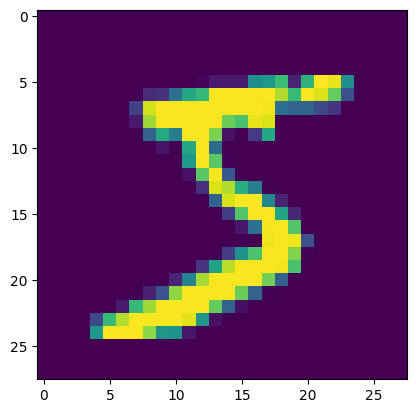

In [118]:
plt.imshow(X_train[0])
plt.show()

In [119]:
print(Y_train[0])

5


In [120]:
#Unique value in Y_train
print(np.unique(Y_train))

#Unique value in Y_test
print(np.unique(Y_test))

[0 1 2 3 4 5 6 7 8 9]
[0 1 2 3 4 5 6 7 8 9]


All the images have the same dimensions in this dataset, If not, we have to resize all the images to a common dimension

In [121]:
# scaling the values

X_train = X_train/255
X_test = X_test/255

In [122]:
print(X_train[0])

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.    

Building a Neural Network

In [123]:
model = keras.Sequential([

      keras.layers.Flatten(input_shape=(28,28)),
      keras.layers.Dense(50,activation ='relu'),
      keras.layers.Dense(50,activation ='relu'),
      keras.layers.Dense(10,activation ='sigmoid')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [124]:
model.compile(
      optimizer = 'adam',
      loss = 'sparse_categorical_crossentropy',
      metrics = ['accuracy']
)

In [125]:
model.fit(X_train , Y_train , epochs = 10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9150 - loss: 0.2948
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9579 - loss: 0.1401
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9686 - loss: 0.1041
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9747 - loss: 0.0836
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9788 - loss: 0.0696
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9818 - loss: 0.0589
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9844 - loss: 0.0503
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9863 - loss: 0.0433
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9877 - loss: 0.0376
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9884 - loss: 0.0338


Accuracy on Test Data

In [126]:
loss , accuracy = model.evaluate(X_test , Y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9694 - loss: 0.1033


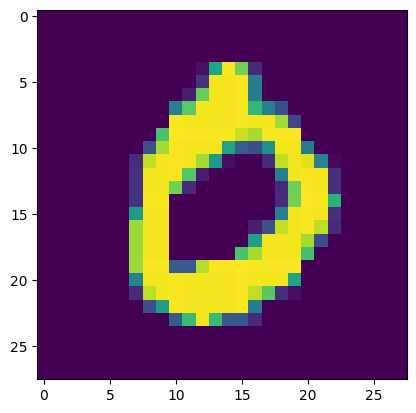

In [127]:
#first data point in X_test
plt.imshow(X_test[3])
plt.show()


In [128]:
print(Y_test[3])

0


In [129]:
Y_pred = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [130]:
Y_pred.shape

(10000, 10)

In [131]:
print(Y_pred[0])

[6.9476068e-02 1.5483787e-06 2.9390359e-01 9.9809200e-01 6.9065593e-09
 9.1883309e-02 1.2911863e-12 9.9999988e-01 4.1429272e-01 9.2798400e-01]


model.predict() gives the prediction probability of each class for that data point

In [132]:
# converting the prediction probabilities to class label
label_for_first_test_image = np.argmax(Y_pred[0])
print(label_for_first_test_image)

7


In [133]:
# converting the prediction probabilities to class label for all test data points
Y_pred_labels = [np.argmax(i) for i in Y_pred]
print(Y_pred_labels)

[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4), np.int64(1), np.int64(4), np.int64(9), np.int64(6), np.int64(9), np.int64(0), np.int64(6), np.int64(9), np.int64(0), np.int64(1), np.int64(5), np.int64(9), np.int64(7), np.int64(3), np.int64(4), np.int64(9), np.int64(6), np.int64(6), np.int64(5), np.int64(4), np.int64(0), np.int64(7), np.int64(4), np.int64(0), np.int64(1), np.int64(3), np.int64(1), np.int64(3), np.int64(4), np.int64(7), np.int64(2), np.int64(7), np.int64(1), np.int64(3), np.int64(1), np.int64(1), np.int64(7), np.int64(4), np.int64(2), np.int64(3), np.int64(5), np.int64(1), np.int64(2), np.int64(4), np.int64(4), np.int64(6), np.int64(3), np.int64(5), np.int64(5), np.int64(6), np.int64(0), np.int64(4), np.int64(1), np.int64(9), np.int64(5), np.int64(7), np.int64(8), np.int64(9), np.int64(3), np.int64(7), np.int64(4), np.int64(6), np.int64(4), np.int64(3), np.int64(0), np.int64(7), np.int64(0), np.int64(2), np.int64(9), np.int64(1), np.int64(7), np.int64(3)

In [134]:
# converting the prediction probabilities to class label for all test data points
Y_pred_labels = [int(np.argmax(i)) for i in Y_pred]
print(Y_pred_labels)

[7, 2, 1, 0, 4, 1, 4, 9, 6, 9, 0, 6, 9, 0, 1, 5, 9, 7, 3, 4, 9, 6, 6, 5, 4, 0, 7, 4, 0, 1, 3, 1, 3, 4, 7, 2, 7, 1, 3, 1, 1, 7, 4, 2, 3, 5, 1, 2, 4, 4, 6, 3, 5, 5, 6, 0, 4, 1, 9, 5, 7, 8, 9, 3, 7, 4, 6, 4, 3, 0, 7, 0, 2, 9, 1, 7, 3, 2, 9, 7, 7, 6, 2, 7, 8, 4, 7, 3, 6, 1, 3, 6, 9, 3, 1, 4, 1, 7, 6, 9, 6, 0, 5, 4, 5, 9, 2, 1, 9, 4, 8, 7, 3, 9, 7, 4, 4, 4, 9, 2, 5, 4, 7, 6, 7, 9, 0, 5, 8, 5, 6, 6, 5, 7, 8, 1, 0, 1, 6, 4, 6, 7, 3, 1, 7, 1, 8, 2, 0, 2, 9, 8, 5, 5, 1, 5, 6, 0, 3, 4, 4, 6, 5, 4, 6, 5, 4, 5, 1, 4, 4, 7, 2, 3, 2, 7, 1, 8, 1, 8, 1, 8, 5, 0, 8, 9, 2, 5, 0, 1, 1, 1, 0, 8, 0, 3, 1, 6, 4, 2, 3, 6, 1, 1, 1, 3, 9, 5, 2, 9, 4, 5, 9, 3, 9, 0, 3, 5, 5, 5, 7, 2, 2, 7, 1, 2, 8, 4, 1, 7, 3, 3, 8, 8, 7, 9, 2, 2, 4, 1, 5, 5, 8, 7, 2, 3, 0, 2, 4, 2, 4, 1, 9, 5, 7, 7, 2, 8, 2, 6, 8, 5, 7, 7, 9, 1, 8, 1, 8, 0, 3, 0, 1, 9, 3, 4, 1, 8, 2, 1, 2, 9, 7, 5, 9, 2, 6, 4, 1, 5, 8, 2, 9, 2, 0, 4, 0, 0, 2, 8, 4, 7, 1, 2, 4, 0, 2, 7, 4, 3, 3, 0, 0, 3, 1, 9, 6, 5, 2, 5, 9, 7, 9, 3, 0, 4, 2, 0, 7, 1, 1, 2, 1, 

Y_test  -->  True labels

Y_pred_labels  -->  Predicted Labels

Confusion matrix


In [135]:
con_mat = confusion_matrix(Y_test , Y_pred_labels)

In [136]:
print(con_mat)

tf.Tensor(
[[ 964    0    0    1    1    2    5    2    1    4]
 [   0 1119    0    5    0    1    2    3    5    0]
 [   1    1  999   11    2    0    3    8    7    0]
 [   0    0    2  992    0    3    2    5    4    2]
 [   0    0    9    0  957    0    5    3    0    8]
 [   2    0    1   41    2  831    5    2    4    4]
 [   5    2    2    1    3    8  936    0    1    0]
 [   2    2    4    6    0    0    1  999    4   10]
 [   0    1    3   14    4    3    1    5  940    3]
 [   0    2    0   15   15    8    0    6    6  957]], shape=(10, 10), dtype=int32)


Text(0.5, 47.7222222222222, 'Predicted Label')

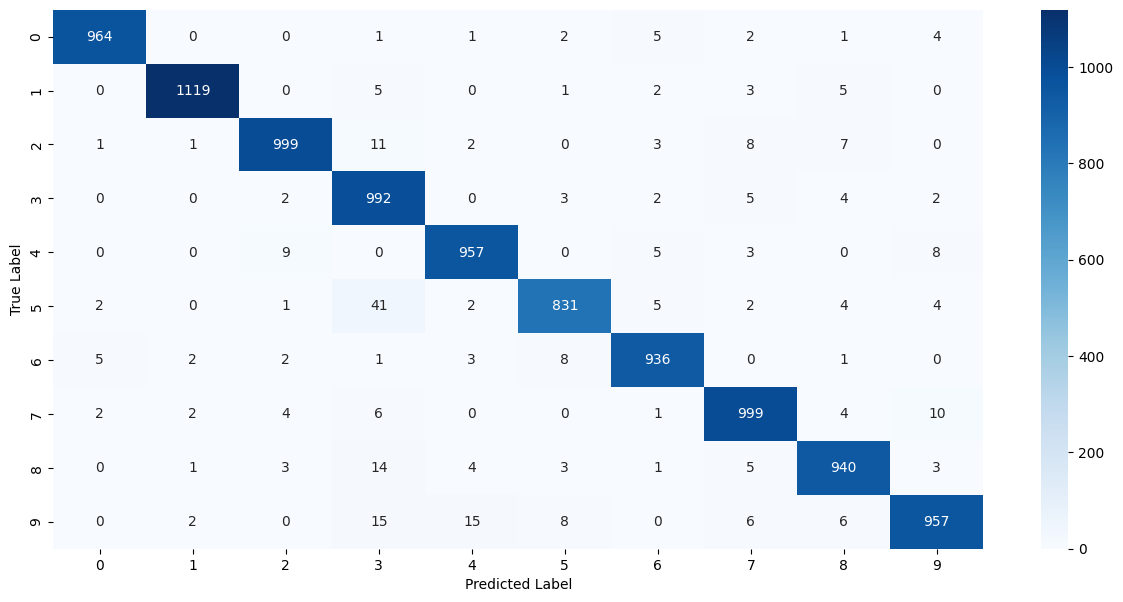

In [137]:
plt.figure(figsize=(15,7))
sns.heatmap(con_mat , annot = True  , fmt = 'd', cmap = 'Blues')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

In [143]:
input_image_path = '/content/Screenshot 2026-07-01 212019.png'
input_image = cv2.imread(input_image_path)

In [144]:
type(input_image)

numpy.ndarray

In [145]:
print(input_image)

[[[25 24 23]
  [25 24 23]
  [25 24 23]
  ...
  [25 24 23]
  [25 24 23]
  [25 24 23]]

 [[25 24 23]
  [25 24 23]
  [25 24 23]
  ...
  [25 24 23]
  [25 24 23]
  [25 24 23]]

 [[25 24 23]
  [25 24 23]
  [25 24 23]
  ...
  [25 24 23]
  [25 24 23]
  [25 24 23]]

 ...

 [[25 24 23]
  [25 24 23]
  [25 24 23]
  ...
  [25 24 23]
  [25 24 23]
  [25 24 23]]

 [[25 24 23]
  [25 24 23]
  [25 24 23]
  ...
  [25 24 23]
  [25 24 23]
  [25 24 23]]

 [[25 24 23]
  [25 24 23]
  [25 24 23]
  ...
  [25 24 23]
  [25 24 23]
  [25 24 23]]]


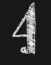

In [146]:
cv2_imshow(input_image)

In [147]:
input_image.shape

(65, 51, 3)

In [148]:
grayscale = cv2.cvtColor(input_image, cv2.COLOR_RGB2GRAY)

In [149]:
grayscale.shape

(65, 51)

In [150]:
input_image_resize = cv2.resize(grayscale, (28, 28))

In [151]:
input_image_resize.shape

(28, 28)

In [152]:
cv2_imshow(input_image_resize)

In [153]:
input_image_resize = input_image_resize/255

In [155]:
type(input_image_resize)

numpy.ndarray

In [154]:
image_reshaped = np.reshape(input_image_resize, [1,28,28])

In [156]:
input_prediction = model.predict(image_reshaped)
print(input_prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
[[1.3105682e-01 3.0438576e-02 6.5843159e-01 9.6304905e-01 2.4950853e-06
  4.7832897e-01 7.0845364e-03 5.5343002e-02 5.3826970e-01 2.3857964e-02]]


In [157]:
input_pred_label = np.argmax(input_prediction)

In [158]:
print(input_pred_label)

3


Predictive System

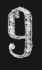

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
The Handwritten Digit is recognised as  9


In [161]:
input_image_path = '/content/Screenshot 2026-07-01 212228.png'

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

grayscale = cv2.cvtColor(input_image, cv2.COLOR_RGB2GRAY)

input_image_resize = cv2.resize(grayscale, (28, 28))

input_image_resize = input_image_resize/255

image_reshaped = np.reshape(input_image_resize, [1,28,28])

input_prediction = model.predict(image_reshaped)

input_pred_label = np.argmax(input_prediction)

print('The Handwritten Digit is recognised as ', input_pred_label)